# Representation of signals & inverse problems - G1-G2

## Lab 3: Source separation and sparsity

## Guidelines (read carefully before starting)

**Objective**: this lab explores a simple procedure to perform a audio source separation.

**Guidelines**: after retrieving the resources for the lab on moodle:

- place the .zip archive in a local folder (Computer -> Documents/Python/);
- unzip the archive .zip;
- rename the folder with the convention lab3_Name1_Name2
- duplicate the notebook file and rename it lab3_Name1_Name2.ipynb;
- [**optional, possibly needed if working from Centrale's machines**]
    - create a `rsp` conda environment from the provided `requirement.txt` file
    ```bash
    conda create --name=rsp --file=requirement.txt
    conda activate rsp
    conda deactivate rsp # to deactivate the conda environment
    # do not forget to deactivate the environment if needed
    # you can remove the environment once you are done
    conda env remove --name=rsp
    ```
    - launch jupyter notebook (the python environment will be the one from the conda environment `rsp`)
- at the end of the session, do not forget to transfer your work to your own network space if you are working on a machine from the school (do not leave your work on the C: drive).
- if needed, an excellent tutorial on the use of Python for scientific computing can be found in the Scipy lecture notes.

**Assessment** → global grade from F to A (A+)

This lab session will be evaluated, based on your answer to the exercises reported in a Jupyter notebook (e.g., this one) and any additional `.py` file produced. Any code produced should be commented whenever appropriate, custom functions and objects documented. Figures produced should be clearly annotated (axis, title, legend whenever appropriate).

1. Numerical correctness
2. Implementation clarity (documentation, relevance of the comments)
3. Answers to the questions and overall presentation of the Jupyter notebook.

## Introduction

Many people listen to recorded music on an everyday basis, *e.g.*, from radio or TV programs, compact discs, downloads, or online streaming services. One may be interested in remixing the balance between the signal sources within the music (*e.g.*, to make the vocals louder or suppress an unwanted sound) or in upmixing a two-channel stereo recording to a 5.1.-channel surround sound system. We might also want to change the spatial location of a musical instrument within the mixture. All these applications are relatively straightforward, provided we can separate the different sound channels (stems) for each musical audio object.

However, if we only have access to the final recorded mixture (as is usually the case), the problem is much more challenging. To estimate the original musical sources, which would allow us to remix, suppress or upmix the sources, we need to perform musical source separation (MSS).

For a general source separation problem, we are given one or more mixture signals that contain different combinations of some original source signals (see Figure 1, where four sources, i.e., vocals, drums, bass, and guitar, are all present in the mixture). The task consists in recovering one or multiple source signals from the observed mixtures. In some cases, this is relatively straightforward, e.g., if there are at least as many mixtures as there are sources and if the mixing process is fixed, with no delays, filters, or nonlinear mastering. Possible references to go beyond the content of this practical session are given below.

> [1] Recent advances in music signal processing, *IEEE Signal Processing Magazine*, vol. 36, Issue 1, Jan. 2019.
>
> [2] Cano, Estefania et al. "Musical Source Separation: An Introduction." IEEE Signal Processing Magazine 36.1 (2019): 31-40.

*(Figure: Audio source separation)*

The set of individual source signals, $s(t) = (s_1(t), \dots, s_n(t))$ (with $n$ the number of sources), is 'mixed' through a matrix, $\mathbf{A} = [a_{ij}]_{i,j} \in \mathbb{R}^{m \times n}$, to produce a set of 'mixed' signals, $x(t) = (x_1(t), \dots, x_m(t))$ (with $m$ the number of recording channels). In practice, $n$ is often equal to $m$. If $m > n$, the system of equations is overdetermined, and can thus be inverted using a conventional linear method. If $n > m$, the system is underdetermined: a non-linear method is needed to properly recover the sources. Note that the signals themselves can be multidimensional, which is the case considered for this practical session.

Each recording channel (left and right in stereo, corresponding to the configuration illustrated above) acquires a signal of the form $x_0(t) = \cos \phi_j s_j(t)$ and $x_1(t) = \sin \phi_j s_j(t)$ respectively, corresponding to a source $j$ in the direction $\phi_j$, for $j = 0, 1, \dots, n$. The $N$ time samples of both signals can be gathered into a matrix `x=[x[0,:]; x[1,:]]`. We then build the mixing matrix $\mathbf{A}$ from the 3 directional mixture pairs of coefficients $(\cos \phi_j, \sin \phi_j)^T$ in column $j$. Observations are thus related to the sources through the following linear equation

$$\mathbf{x} = \mathbf{A}\mathbf{s}$$

where $\mathbf{x} \in \mathbb{R}^{m \times N}$ contains the observations, $\mathbf{s} \in \mathbb{R}^{n \times N}$ contains the sources, $\mathbf{A} \in \mathbb{R}^{m \times n}$ and $N$ is the number of time samples.

The above equation will be effectively inverted using a blind source separation (BSS) approach. BSS separates the set of mixed signals $x$ through the determination of an 'unmixing' matrix $\mathbf{B} = [b_{ij}] \in \mathbb{R}^{n \times m}$, to recover an approximation to the original signals, $y(t) = (y_1(t), \dots, y_n(t))^T$.

$$\mathbf{y} = \hat{\mathbf{s}} = \mathbf{B}\mathbf{x}$$

This practical session will be focussed on a BSS approach based on 2 main ingredients. The first step consists in exploiting the redundancy of the time-frequency representation. It appears that the STFT partially separates the contribution of each source to the mixture, characterized by a distinct energy pattern in the time-frequency space (spectrogram). A second step will explore the combination of the left and right channels to estimate the direction of arrival (DOA) of each source. A clustering step will finally allow a DOA to be associated to each coefficient of the STFT of the available observations (the left and right channels). This will yield an even better separation result. An example of the kind of results expected from this approach is represented in the time-frequency plane in the figure below (each color corresponds to a different source).

*(Figure: Time-Frequency plan)*

## A typical musical source separation (MSS) workflow

A high-level overview of the steps involved in most MSS systems is illustrated below. The input mixture signal $x$ is first transformed to the time-frequency (TF) domain. The TF representation of the signal $X$ is then manipulated to obtain parameters that model the individual sources $\hat{S}_i$ in the mixture. These are then used to create filters to yield TF estimates $\hat{Y}_i$ of the sources. This is typically done in an iterative manner before the final estimated time domain signals $\hat{y}_i$ are recovered via an inverse TF transform.

## Contents

This practical session is structured around the 4 following steps.

1. Preparing the data: sound mixing
    - execute the python codes and read the associated explanations to go through the following exercises
2. Local Fourier analysis of sounds
    - Exercise 1
3. Estimation of the mixing matrix A by clustering
    - Exercise 2
    - Exercise 3
4. Source separation using clustering
    - Exercise 4
    - Exercise 5 (optional)

#### Configuration

> **About the resources of this folder**
>
> - `nt_toolbox/data/bird.wav`, `female.wav`, `male.wav` are the audio tracks of the course (16384 samples at 15000 Hz).
> - `nt_toolbox/` is a minimal version of the toolbox provided on Moodle (only `load_sound` is used).

In [1]:
# make sure the notebook reloads the module each time we modify it
%load_ext autoreload
%autoreload 2

# figures displayed below the cells
%matplotlib inline

In [2]:
import numpy as np
import math
from scipy.signal import *
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
from IPython.display import Audio, display

from nt_toolbox.general import *
from nt_toolbox.signal import *

import warnings

warnings.filterwarnings("ignore")

## Preparing the data: sound mixing

We first load 3 reference sounds (*sources*) and simulate a stereo recording by generating a linear mixture of the sounds.

#### Sound loading:

In [3]:
from nt_toolbox.load_sound import *

fs = 15000  # the same for all sources (cheating a little ;-)

N = 1024 * 16
n = 3  # number of sounds
m = 2  # number of micros

s = np.zeros([3, N])
s[0, :] = load_sound("nt_toolbox/data/bird.wav", N)
s[1, :] = load_sound("nt_toolbox/data/female.wav", N)
s[2, :] = load_sound("nt_toolbox/data/male.wav", N)

In [4]:
from IPython.display import Audio

Audio(s[0, :], rate=fs)

In [5]:
Audio(s[1, :], rate=fs)

In [6]:
Audio(s[2, :], rate=fs)

#### Normalize the energy of the signals

This normalization step is simply aimed at simulating a situation where all the sources have a similar level of energy.

In [7]:
s = s / np.tile(np.std(s, 1), (N, 1)).T

We mix the sound using a $2 \times 3$ mixing matrix $A$. The weights are determined by the direction of arrival of the acoustic wave produced by each source. In this example, the directions are well-spaced, but you can try with more complicated mixing matrices.

#### Build the mixing matrix

In [8]:
phi = [np.pi / 6, np.pi / 2, np.pi * 5 / 6]  # angles = directions of arrival of the 3 sources
print("Angles (rad) : ", phi)

Angles (rad) :  [0.5235987755982988, 1.5707963267948966, 2.6179938779914944]


Mixing matrix:

In [9]:
A = np.vstack((np.cos(phi), np.sin(phi)))
print("A = ", A)

A =  [[ 8.66025404e-01  6.12323400e-17 -8.66025404e-01]
 [ 5.00000000e-01  1.00000000e+00  5.00000000e-01]]


Compute the mixed sources $x = As$.

In [10]:
x = A.dot(s)

Display of the sources.

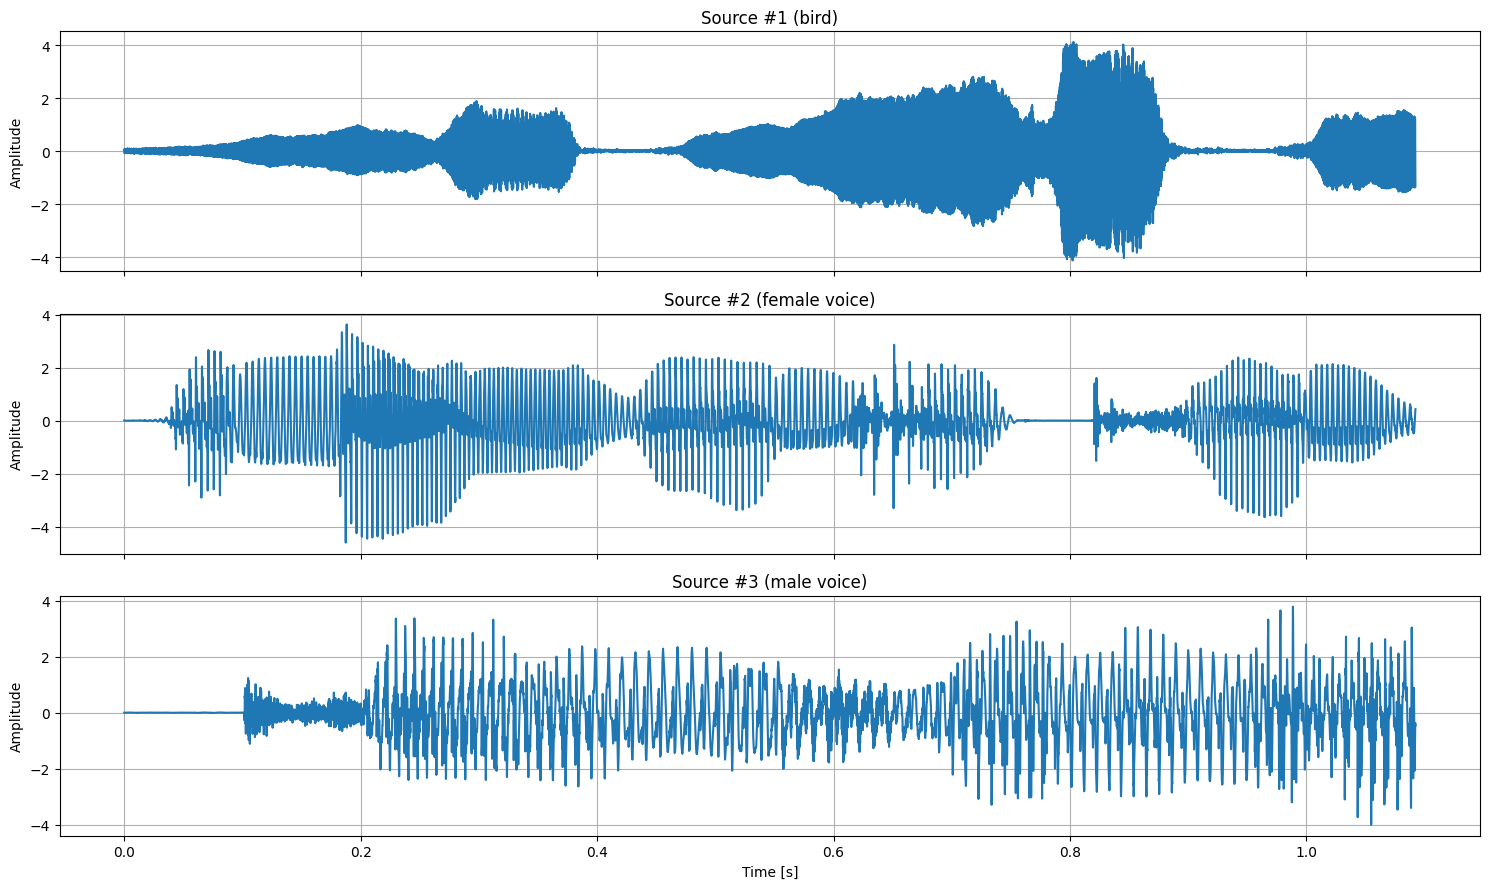

In [11]:
t = np.arange(0, N) / fs
names = ["bird", "female voice", "male voice"]
fig, axes = plt.subplots(n, 1, figsize=(15, 9), sharex=True)
for i in range(n):
    axes[i].plot(t, s[i, :])
    axes[i].set_title("Source #%i (%s)" % (i + 1, names[i]))
    axes[i].set_ylabel("Amplitude")
    axes[i].grid()
axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

Displaying the micros outputs (left and right channel, mixtures a several sources):

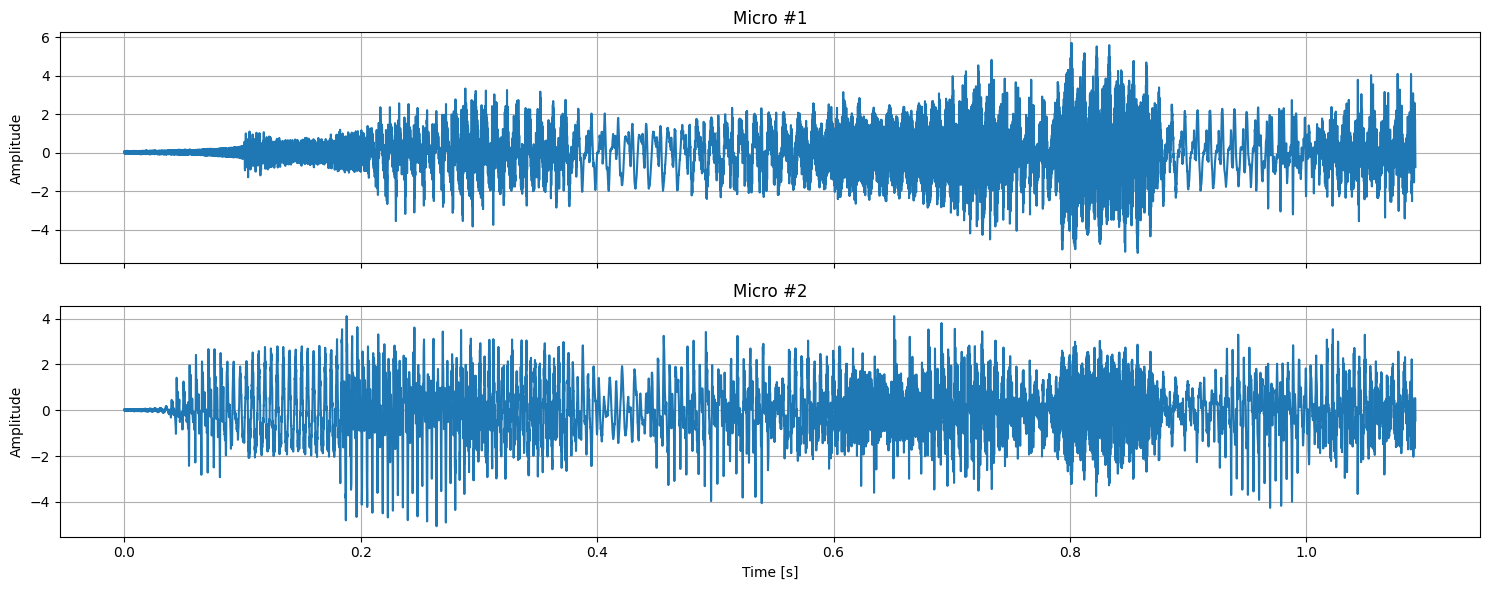

In [12]:
fig, axes = plt.subplots(m, 1, figsize=(15, 6), sharex=True)
for i in range(m):
    axes[i].plot(t, x[i, :])
    axes[i].set_title("Micro #%i" % (i + 1))
    axes[i].set_ylabel("Amplitude")
    axes[i].grid()
axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

In [13]:
Audio(x[0, :], rate=fs)

In [14]:
Audio(x[1, :], rate=fs)

### Ready to go for music source separation !

## Local Fourier analysis of sounds

As a first step towards source separation, we perform a short term Fourier transform (STFT) of the sounds recorded by both channels. The hope is that the sources will be well- separated over the time-frequency domain because the sources are sparse after a STFT, due to its redundancy.

## Exercise 1

1. Set up the parameters for the STFT, and compute the STFT of the original sources `s`. Show their spectrogram.
2. Compute the STFT and represent the spectrogram of the 2 mixed channels `x`. Store them in an array `X` so that `X[i,:,:]` is the STFT of the channel `i`.
3. Observe and comment.

*Indication: you can use the function below if you want to compute the STFT and plot spectrograms.*

In [15]:
def myplot_spectrogram(x, fs, w, q):
    # w = 128   #size of the window
    # q = w//4  #overlap of the window
    plt.figure(figsize=(15, 3))
    f, t, Zxx = stft(x, fs=fs, window="hann", nperseg=w, noverlap=q)
    plt.pcolormesh(t, f, np.abs(Zxx), cmap="jet", norm=LogNorm())
    plt.ylabel("Frequency [Hz]")
    plt.xlabel("Time [sec]")
    plt.colorbar()
    return Zxx

### Answers to Exercise 1

**Question 1.** STFT parameters: Hann window of `width` = 128 samples (8.5 ms) with an overlap of `width`/4, as in the provided function. The true sampling frequency is used so that the axes are in seconds and Hz.

Window: 8.5 ms, hop: 96 samples, frequency step: 117.2 Hz


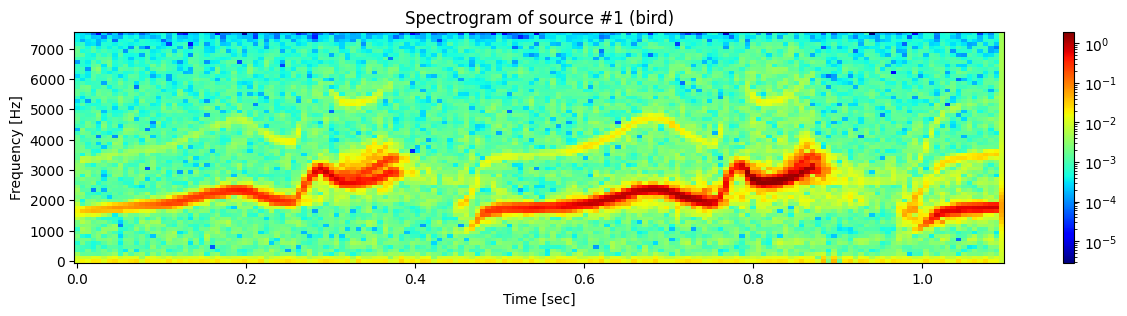

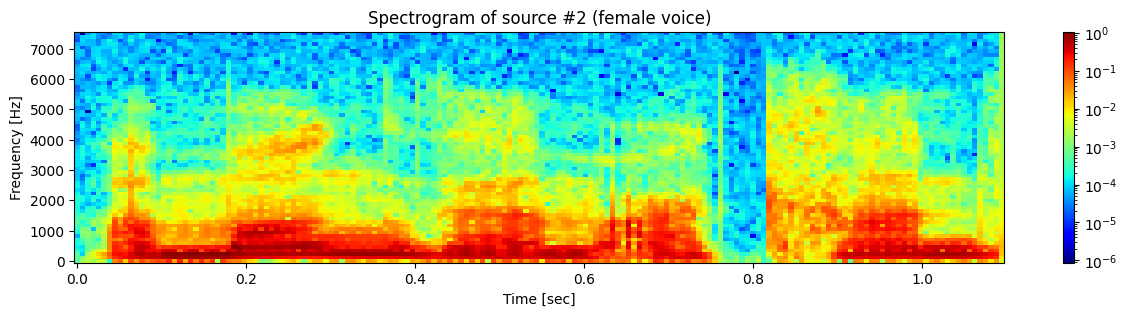

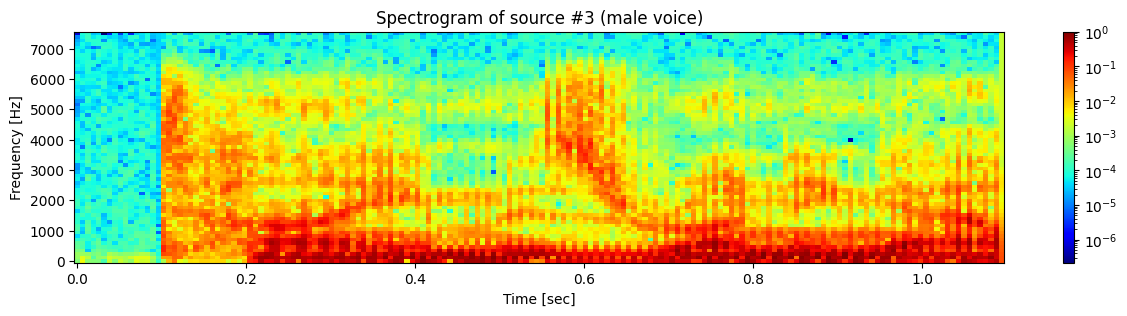

In [16]:
width = 128  # window length [samples]
q = width // 4  # overlap [samples]
print("Window: %.1f ms, hop: %d samples, frequency step: %.1f Hz" % (1000 * width / fs, width - q, fs / width))

S_list = []
for i in range(n):
    S_list.append(myplot_spectrogram(s[i, :], fs, width, q))
    plt.title("Spectrogram of source #%i (%s)" % (i + 1, names[i]))
    plt.show()
S = np.array(S_list)  # STFT of the sources, shape (3, frequencies, frames)

**Question 2.** STFT of the two channels, stored in `X` (`X[i, :, :]` is the STFT of channel `i`).

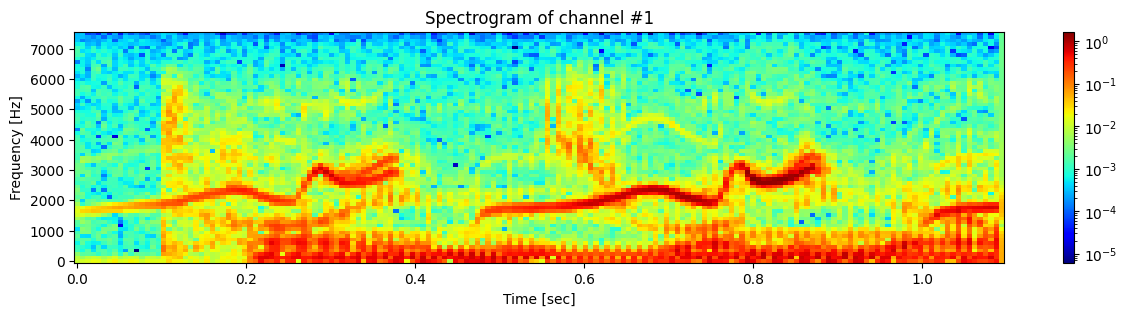

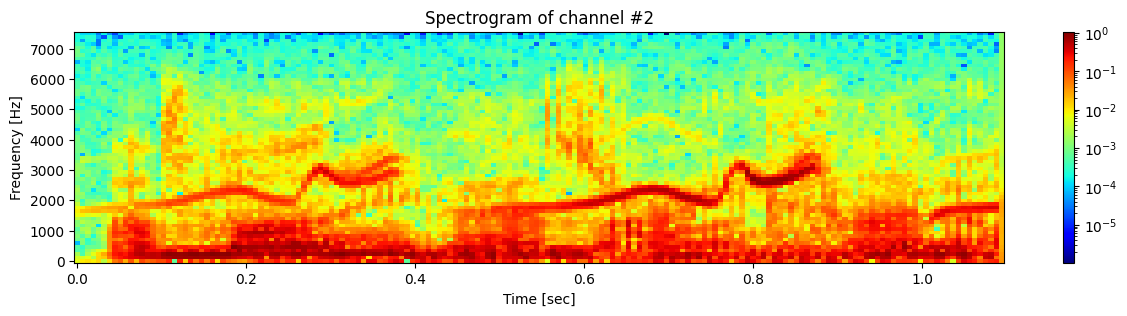

X.shape = (2, 65, 172) (channels, frequencies, frames)


In [17]:
X_list = []
for i in range(m):
    X_list.append(myplot_spectrogram(x[i, :], fs, width, q))
    plt.title("Spectrogram of channel #%i" % (i + 1))
    plt.show()
X = np.array(X_list)
print("X.shape =", X.shape, "(channels, frequencies, frames)")

**Question 3.** To quantify how much the sources overlap in the time-frequency plane, we measure, for each STFT coefficient, the share of energy of the dominant source.

Share of the total energy located in coefficients where one source holds more than 50 % of the energy: 100.0 %
Share of the total energy located in coefficients where one source holds more than 80 % of the energy: 77.0 %
Share of the total energy located in coefficients where one source holds more than 90 % of the energy: 65.1 %
Share of the total energy located in coefficients where one source holds more than 99 % of the energy: 52.4 %
Source 1 (bird): 90 % of the energy in 1.7 % of the STFT coefficients
Source 2 (female voice): 90 % of the energy in 5.2 % of the STFT coefficients
Source 3 (male voice): 90 % of the energy in 4.5 % of the STFT coefficients


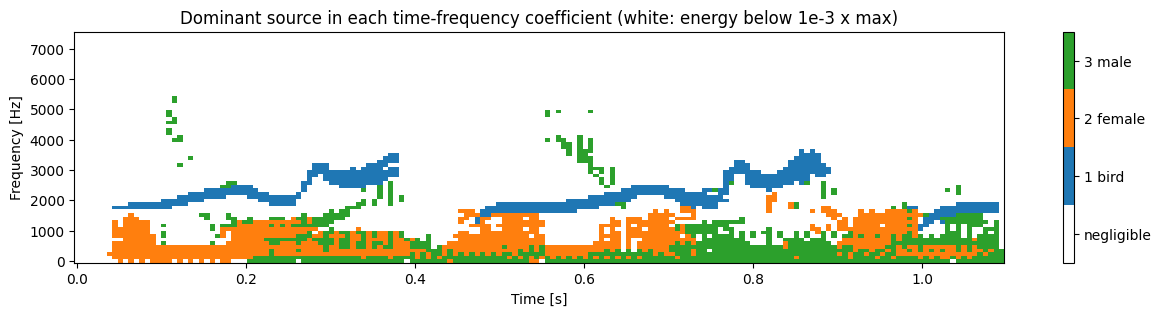

In [18]:
energy_sources = np.abs(S) ** 2  # (3, F, T)
total = energy_sources.sum(axis=0)
dominance = energy_sources.max(axis=0) / np.maximum(total, 1e-20)
weights = total / total.sum()
for level in [0.5, 0.8, 0.9, 0.99]:
    print("Share of the total energy located in coefficients where one source holds more than %2d %% of the energy: %.1f %%"
          % (100 * level, 100 * weights[dominance > level].sum()))

# largest coefficients: how many are needed to capture 90 % of the energy of each source?
for i in range(n):
    e = np.sort(energy_sources[i].ravel())[::-1]
    k90 = np.searchsorted(np.cumsum(e) / e.sum(), 0.9) + 1
    print("Source %d (%s): 90 %% of the energy in %.1f %% of the STFT coefficients" % (i + 1, names[i], 100 * k90 / e.size))

plt.figure(figsize=(15, 3))
plt.pcolormesh(np.arange(S.shape[2]) * (width - q) / fs, np.arange(S.shape[1]) * fs / width,
               np.where(total > 1e-3 * total.max(), np.argmax(energy_sources, axis=0) + 1, 0),
               cmap=ListedColormap(["white", "tab:blue", "tab:orange", "tab:green"]), vmin=-0.5, vmax=3.5, shading="auto")
cbar = plt.colorbar(ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(["negligible", "1 bird", "2 female", "3 male"])
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title("Dominant source in each time-frequency coefficient (white: energy below 1e-3 x max)")
plt.show()

**Observations.**

- **Each source occupies a small part of the time-frequency plane.** The bird is a thin, time-varying line between 1500 and 3500 Hz (plus a weak harmonic), the two voices are made of harmonic combs below 1500 Hz during the voiced parts, with short wideband bursts for the consonants (for instance around 0.1 s and 0.57 s for the male voice). 90 % of the energy of each source is carried by only **1.7 % (bird), 5.2 % (female) and 4.5 % (male)** of the STFT coefficients: the sources are **sparse** in the STFT domain, whereas in the time domain they are all active almost all the time.
- **The sources rarely overlap.** Although the voices share the low frequencies, their harmonics are at different frequencies and their syllables at different times, so that most coefficients are dominated by one source only: 77 % of the total energy lies in coefficients where one source carries more than 80 % of the energy, and 52 % where it carries more than 99 %. The mixture is therefore almost *W-disjoint orthogonal*, which is the assumption that makes the separation possible.
- **The spectrograms of the channels are weighted superpositions of those of the sources**, with weights given by the columns of $A$ (for the moduli, the superposition is exact only where the sources do not overlap). Channel 1 receives $0.87\,s_1 + 0\,s_2 - 0.87\,s_3$: the female voice, which comes from $\phi = \pi/2$, is **absent from the left channel** (its low-frequency formants at 0.05 s and 1.0 s are missing on the first spectrogram). Channel 2 receives $0.5\,s_1 + s_2 + 0.5\,s_3$: the female voice is at full level and the bird and the male voice are attenuated by a factor 2. The ratio between the two channels thus depends on the source, which is what the next exercises exploit.

## Estimation of the mixing matrix $A$ by clustering

The sources appear to be sparse in the time-frequency plane. Now we focus on separating these even more using their direction of arrival. Indeed, considering both the left and right channels as the components of a vector, each source is expected to be aligned with one direction $(\cos \phi_{j}, \sin \phi_{j})$ in particular.

Therefore, the STFT coefficients, at a given time and frequency in the left and right channel, are expected to be such that $X_{\mathrm{left}} = \cos \phi_j S_j$ and $X_{\mathrm{right}} = \sin \phi_j S_j$, where $S_j$ is the STFT of the source $j$. One can expect to separate the sources by identifying their direction of arrival, estimated from the ratio between the right and left channels, that is $\tan \phi_j$.

Before starting this exercise, read carefully the section `Musical source position model`, p. 35 from the supplementary article Cano et al. 2019 (made available on Moodle).

### Exercise 2

1. In the time domain, represent `x_1 = x[1,:]` as a function of `x_0 = x[0,:]`. What do you observe? Do you think it can help in separating sources?
2. Reshape the STFTs contained in `X` (last two dimensions) to obtain a matrix `Xvec[:,i]` for `i=0,1` (i.e., `Xvec[:,i]` contains a vectorized version of the STFT of `x[i,:]` ). *Indication: use* `np.reshape` *.*
3. Concatenate the real and imaginary parts of `Xvec` along the axis 0, forming an array `Xr`.
4. Plot `Xr[:,1]` as a function of `Xr[:,0]`. Observe and comment. Do you think it can help in separating sources?
5. Compute the histogram of `arctan(Xr[:,1]/Xr[:,0])`.
6. Propose a method to estimate the direction of each source.

*Indication: the functions `np.histogram`, `plt.hist` and `np.arctan2` may be useful. Make sure you are working with angles in $[0, \pi)$ by considering `np.arctan2(...)%np.pi`.*

### Answers to Exercise 2

**Question 1.**

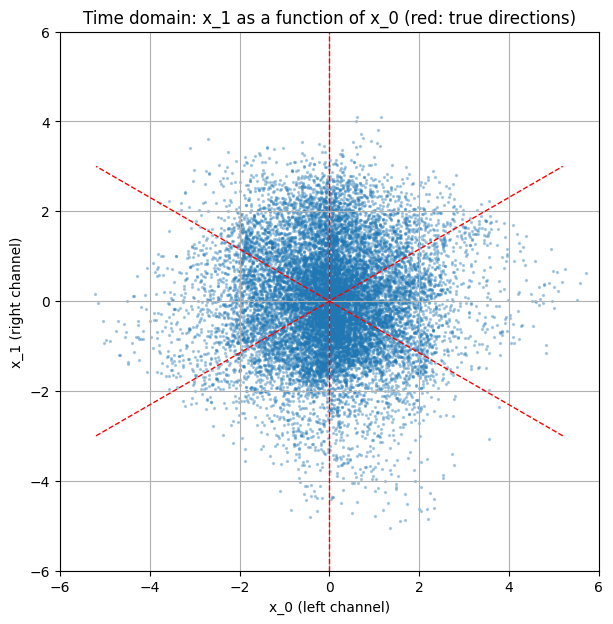

In [19]:
x_0 = x[0, :]
x_1 = x[1, :]

plt.figure(figsize=(7, 7))
plt.scatter(x_0, x_1, s=2, alpha=0.3)
for p in phi:
    plt.plot([-6 * np.cos(p), 6 * np.cos(p)], [-6 * np.sin(p), 6 * np.sin(p)], "r--", linewidth=1)
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.gca().set_aspect("equal")
plt.xlabel("x_0 (left channel)")
plt.ylabel("x_1 (right channel)")
plt.title("Time domain: x_1 as a function of x_0 (red: true directions)")
plt.grid()
plt.show()

In the time domain, the points $(x_0(t), x_1(t))$ form a **shapeless elliptical cloud**, and no preferred direction can be seen. At almost every instant the three sources are active simultaneously, so each sample is a combination $s_1(t)\,u_1 + s_2(t)\,u_2 + s_3(t)\,u_3$ of the three direction vectors with comparable weights, which fills the plane. This representation does not help to separate the sources.

**Question 2.**

In [20]:
mf = np.shape(X)[1]  # number of frequencies
mt = np.shape(X)[2]  # number of frames

Xvec = np.zeros((mt * mf, m), dtype="complex")
Xvec[:, 0] = np.reshape(X[0, :, :], (mt * mf,))
Xvec[:, 1] = np.reshape(X[1, :, :], (mt * mf,))
print("Xvec.shape =", Xvec.shape)

Xvec.shape = (11180, 2)


**Question 3.** The real and imaginary parts are stacked along axis 0: each complex coefficient gives two points of $\mathbb{R}^2$.

In [21]:
Xr = np.concatenate((np.real(Xvec), np.imag(Xvec)), axis=0)
print("Xr.shape =", Xr.shape)

Xr.shape = (22360, 2)


**Question 4.**

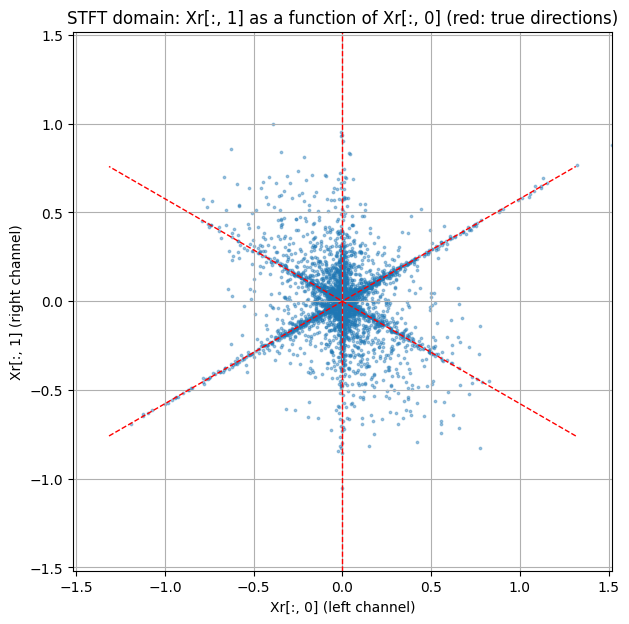

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(Xr[:, 0], Xr[:, 1], s=3, alpha=0.4)
lim = np.abs(Xr).max()
for p in phi:
    plt.plot([-lim * np.cos(p), lim * np.cos(p)], [-lim * np.sin(p), lim * np.sin(p)], "r--", linewidth=1)
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.gca().set_aspect("equal")
plt.xlabel("Xr[:, 0] (left channel)")
plt.ylabel("Xr[:, 1] (right channel)")
plt.title("STFT domain: Xr[:, 1] as a function of Xr[:, 0] (red: true directions)")
plt.grid()
plt.show()

In the STFT domain, the cloud has a **star shape made of three lines through the origin**, which coincide with the true directions $\pi/6$, $\pi/2$ and $5\pi/6$ (red). Since the mixing is real and instantaneous, a coefficient dominated by source $j$ satisfies $X(t, f) \approx S_j(t, f)\,(\cos\phi_j, \sin\phi_j)$: both its real part and its imaginary part lie on the line of direction $\phi_j$, at a distance proportional to $|S_j|$. The sparsity of the sources in the STFT domain turns the mixture into a union of lines. The points between the lines correspond to coefficients where several sources overlap, and most of the points are concentrated near the origin (72 % of them have an amplitude below 1 % of the maximum).

This representation is therefore very useful: the directions of arrival can be read on it, and each coefficient can be assigned to the closest line.

**Question 5.**

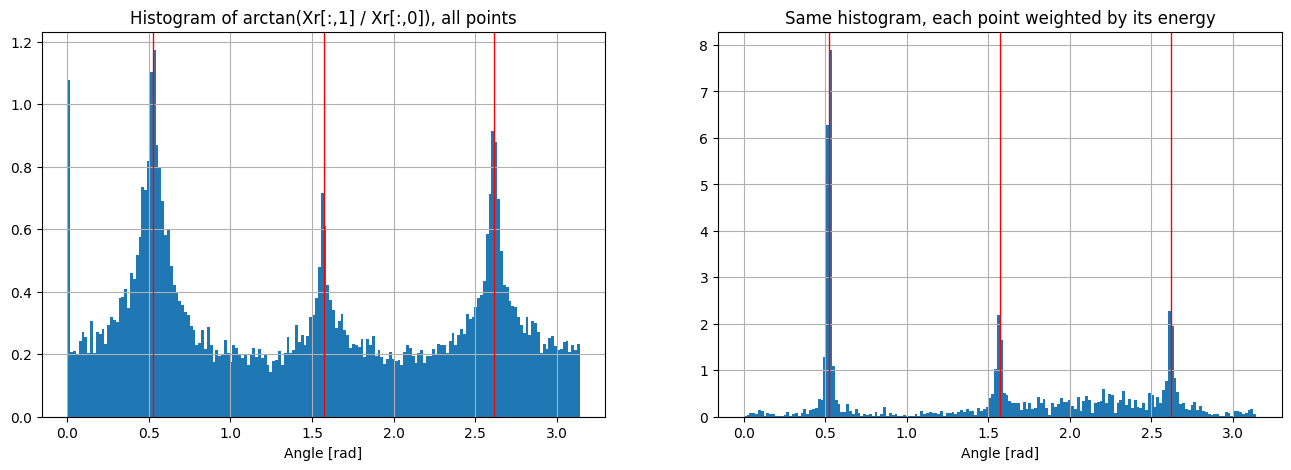

Share of the points with an amplitude below 1 % of the maximum: 72.1 %


In [23]:
angles = np.arctan2(Xr[:, 1], Xr[:, 0]) % np.pi
amplitude = np.hypot(Xr[:, 0], Xr[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(angles, bins=180, density=True)
axes[0].set_title("Histogram of arctan(Xr[:,1] / Xr[:,0]), all points")
axes[1].hist(angles, bins=180, density=True, weights=amplitude ** 2)
axes[1].set_title("Same histogram, each point weighted by its energy")
for ax in axes:
    for p in phi:
        ax.axvline(x=p, c="r", linewidth=1)
    ax.set_xlabel("Angle [rad]")
    ax.grid()
plt.show()
print("Share of the points with an amplitude below 1 %% of the maximum: %.1f %%"
      % (100 * np.mean(amplitude < 0.01 * amplitude.max())))

**Question 5.** The histogram of the angles shows **three peaks at the true directions**, on top of a flat background. The background comes from the many low-energy points (noise-like coefficients of the silences, overlaps), whose angle is almost random. The isolated peak at exactly 0 is an artefact: for the frequency bins $f = 0$ and $f = f_s/2$ the STFT coefficients are real, so their imaginary parts are exactly zero in both channels (344 points at the origin), and `arctan2(0, 0)` returns 0.

Weighting each point by its energy (right) removes most of this background, since the low-energy points hardly count, and the three peaks become much sharper.

**Question 6. Proposed method.** (1) Compute the STFT of both channels. (2) Keep only the coefficients with a significant energy, since they are the ones dominated by a single source and the only ones with a reliable angle. (3) Compute their angle $\theta = \arctan(X_1 / X_0)$ modulo $\pi$ (the sign of the coefficient does not matter). (4) Build an energy-weighted histogram of $\theta$. (5) Take the positions of its $n$ highest peaks, possibly refined by an average of the angles around each peak, as estimates of $\phi_1, \dots, \phi_n$, and build $\hat{A}$ from them. This is what Exercise 3 implements.

### Exercise 3

The histogram computed from the whole set of points is not peacked enough. To stabilize the detection of the mixing directions and obtain more accurate estimates, we will compute an histogram from a reduced set of points of largest amplitude.

1. Compute the energy of each point.
2. Extract only a sub-set of the points from each STFT (left and right) by simultaneously selecting coefficients above a given energy threshold (extract the same points for both channels).
3. Compute the histogram of the estimated directions for this subset only; you will need to empirically adjust the threshold to conduct the above step.
4. Estimate the directions of the sources as accurately as possible.
5. Compare your results with the true mixing matrix `A` and comment on them.

*Indication: the function* `np.where` *and* `np.argmax` *may help you to localize and select coefficients.*

### Answers to Exercise 3

**Question 1.** Energy of each point of `Xr`.

50 % of the energy is carried by the 1.42 % largest points
90 % of the energy is carried by the 6.62 % largest points
99 % of the energy is carried by the 15.34 % largest points


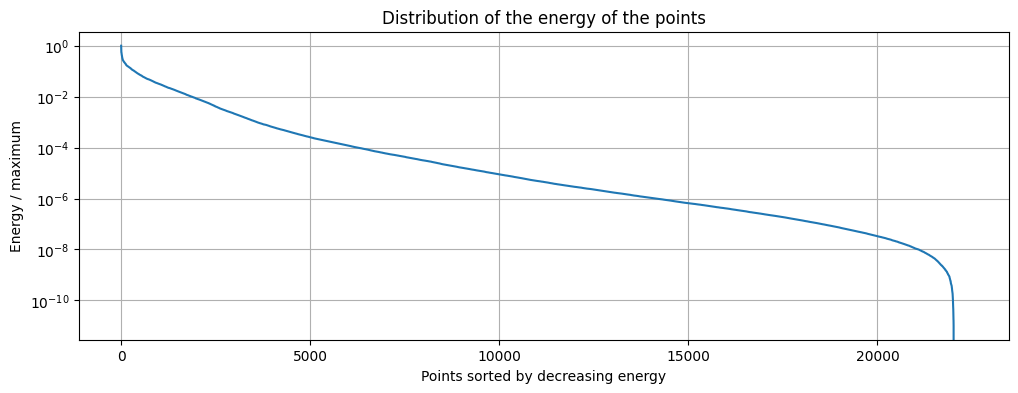

In [24]:
energy = Xr[:, 0] ** 2 + Xr[:, 1] ** 2
max_energy = energy.max()
e_sorted = np.sort(energy)[::-1]
for share in [0.5, 0.9, 0.99]:
    k = np.searchsorted(np.cumsum(e_sorted) / e_sorted.sum(), share) + 1
    print("%2d %% of the energy is carried by the %.2f %% largest points" % (100 * share, 100 * k / energy.size))

plt.figure(figsize=(12, 4))
plt.semilogy(e_sorted / max_energy)
plt.xlabel("Points sorted by decreasing energy")
plt.ylabel("Energy / maximum")
plt.title("Distribution of the energy of the points")
plt.grid()
plt.show()

**Questions 2 and 3.** Selection of the points above a threshold (same points for both channels, since the energy combines them), and histogram of their angles for several thresholds.

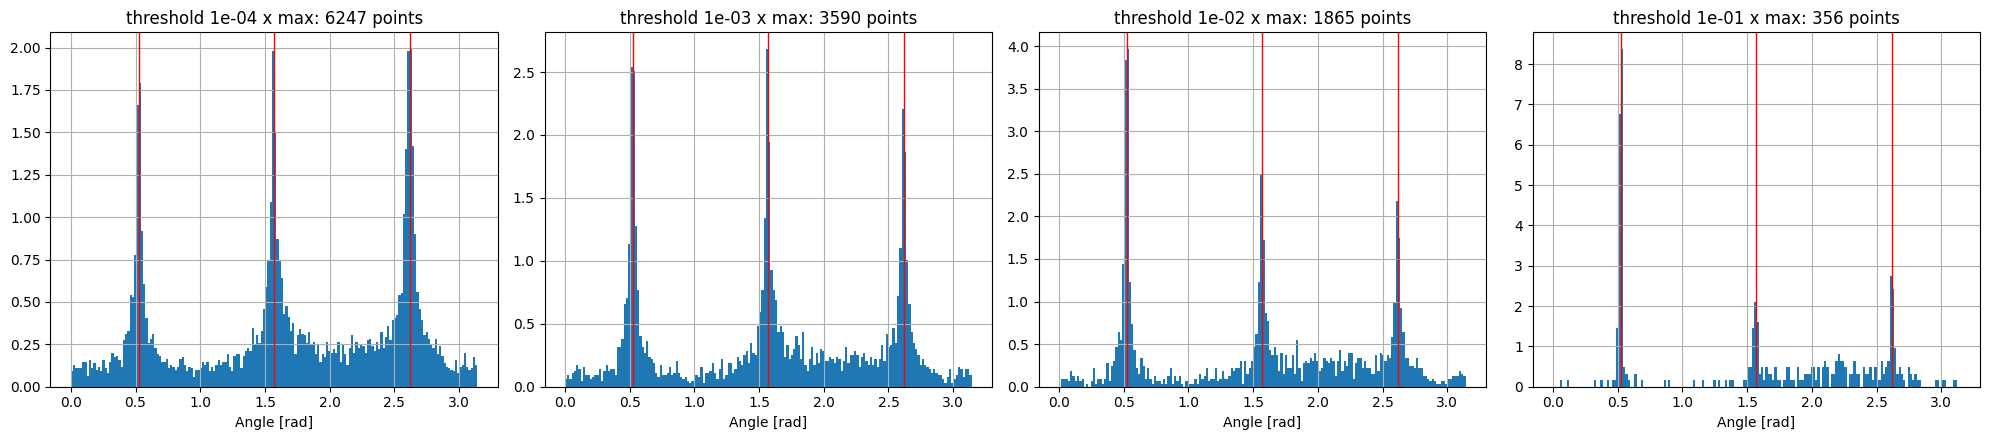

In [25]:
thresholds = [1e-4, 1e-3, 1e-2, 1e-1]
fig, axes = plt.subplots(1, len(thresholds), figsize=(20, 4.5), sharey=False)
for ax, th in zip(axes, thresholds):
    index = np.where(energy > th * max_energy)[0]
    angles_sub = np.arctan2(Xr[index, 1], Xr[index, 0]) % np.pi
    ax.hist(angles_sub, bins=180, range=(0, np.pi), density=True)
    for p in phi:
        ax.axvline(x=p, c="r", linewidth=1)
    ax.set_title("threshold %.0e x max: %d points" % (th, index.size))
    ax.set_xlabel("Angle [rad]")
    ax.grid()
plt.tight_layout()
plt.show()

The energy is extremely concentrated: 50 % of it is carried by 1.4 % of the points, and 90 % by 6.6 % of the points. Keeping only the points above a threshold removes the low-energy points with random angles, and the peaks rise above the background:

- $10^{-4}$ × max (6247 points): the three peaks are visible but still on a significant background;
- $10^{-3}$ and $10^{-2}$ × max (3590 and 1865 points): the background is strongly reduced and the peaks are narrow; this is the best range;
- $10^{-1}$ × max (356 points): only the loudest coefficients remain, most of them belonging to the bird, so the peak at $\pi/6$ dominates and the two other peaks are defined by few points (less robust estimate).

A threshold of $10^{-2}$ × max is kept for the estimation. The remaining background between $\pi/2$ and $5\pi/6$ comes from coefficients where the two voices overlap in the low frequencies.

**Question 4.** Estimation of the three directions: peaks of the histogram of the selected points (threshold $10^{-2}$), refined by the energy-weighted mean of the angles around each peak.

Estimated directions (rad): [0.5233 1.5656 2.612 ]
True directions      (rad): [0.5236 1.5708 2.618 ]
Errors (degrees):           [-0.02 -0.3  -0.34]


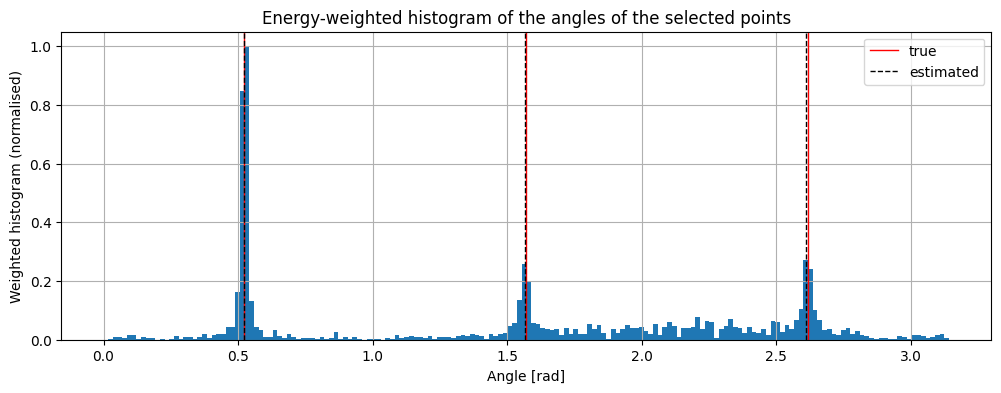

In [26]:
threshold = 1e-2 * max_energy
index = np.where(energy > threshold)[0]
angles_sub = np.arctan2(Xr[index, 1], Xr[index, 0]) % np.pi
energy_sub = energy[index]

y_hist, edges = np.histogram(angles_sub, bins=180, range=(0, np.pi), weights=energy_sub)
centres = (edges[:-1] + edges[1:]) / 2
peaks, _ = find_peaks(np.concatenate(([0], y_hist, [0])), distance=20)  # peaks at least 20 degrees apart
peaks = peaks - 1
peaks = peaks[np.argsort(y_hist[peaks])[::-1][:n]]  # the n highest peaks
peaks = np.sort(peaks)

result = []
for p in peaks:
    near = np.abs(angles_sub - centres[p]) < np.deg2rad(5)  # points within 5 degrees of the peak
    result.append(np.sum(angles_sub[near] * energy_sub[near]) / np.sum(energy_sub[near]))
result = np.array(result)

print("Estimated directions (rad):", np.round(result, 4))
print("True directions      (rad):", np.round(phi, 4))
print("Errors (degrees):          ", np.round(np.rad2deg(result - np.array(phi)), 2))

plt.figure(figsize=(12, 4))
plt.bar(centres, y_hist / y_hist.max(), width=np.pi / 180)
for p in phi:
    plt.axvline(p, color="r", linewidth=1, label="true" if p == phi[0] else None)
for r in result:
    plt.axvline(r, color="k", linestyle="--", linewidth=1, label="estimated" if r == result[0] else None)
plt.xlabel("Angle [rad]")
plt.ylabel("Weighted histogram (normalised)")
plt.title("Energy-weighted histogram of the angles of the selected points")
plt.legend()
plt.grid()
plt.show()

The three peaks of the energy-weighted histogram (1° bins, peaks at least 20° apart), refined by the energy-weighted mean of the angles within ±5° of each peak, give:

| source | true direction | estimate | error |
| --- | --- | --- | --- |
| bird | 0.5236 rad (30°) | 0.5233 rad | -0.02° |
| female voice | 1.5708 rad (90°) | 1.5656 rad | -0.30° |
| male voice | 2.6180 rad (150°) | 2.6120 rad | -0.34° |

The directions are recovered with an error smaller than 0.35°, i.e. better than the width of a histogram bin, thanks to the refinement step. The bird, whose coefficients are the most isolated in the time-frequency plane, gives the most accurate estimate. The estimates of the two voices are slightly less accurate: their peaks are lower and sit on the background created by the coefficients where they overlap, which lie between the lines and slightly shift the weighted mean.

**Question 5.**

In [27]:
A_est = np.vstack((np.cos(result), np.sin(result)))
np.set_printoptions(precision=4, suppress=True)
print("True mixing matrix A:\n", A)
print("Estimated mixing matrix:\n", A_est)
print("Maximum absolute difference: %.4f" % np.abs(A - A_est).max())
print("Angles between true and estimated columns (degrees):",
      np.round(np.rad2deg(np.arccos(np.clip(np.sum(A * A_est, axis=0), -1, 1))), 2))

True mixing matrix A:
 [[ 0.866  0.    -0.866]
 [ 0.5    1.     0.5  ]]
Estimated mixing matrix:
 [[ 0.8662  0.0052 -0.863 ]
 [ 0.4997  1.      0.5052]]
Maximum absolute difference: 0.0052
Angles between true and estimated columns (degrees): [0.02 0.3  0.34]


The estimated mixing matrix is very close to the true one: the largest difference between their coefficients is 0.005, and the angle between each true column and its estimate is at most 0.34°. The entry $A_{0,1} = \cos(\pi/2)$ is 0 in theory ($6 \times 10^{-17}$ numerically) and 0.005 for the estimate: this is not a larger error than for the other coefficients, it only looks different because the true value is zero, so any error, however small, appears as a "different" coefficient. Near $\phi = \pi/2$, $\cos\phi$ varies as fast as possible, so an error of 0.3° gives a change of 0.005 in the first row, whereas the second row ($\sin\phi \approx 1$) is almost insensitive.

The estimation is thus accurate, but it relies on assumptions that hold in this simulation: an instantaneous (no delay, no reverberation), real-valued mixing, well-spaced directions (60° apart) and sources that are sparse and rarely overlap in the STFT domain. With closer directions or more overlapping sources, the peaks would merge and the estimate would degrade.

## Source separation using clustering

Once the mixing directions are known, one can project the sources onto the estimated directions. The direction which best suits a given source is the one with the highest level of energy (the source is "aligned" with this direction).

We now compute the projection of the coefficients `X` onto each of the estimated directions. Each coefficient will be associated to the direction with the highest level of energy.

### Exercise 4

1. In your own words, explain and justify the proposed approach.
2. Build the estimated set of directions $\hat{\phi}_k$ and group them in a projection matrix `P`: one direction $(\cos \hat{\phi}_k, \sin \hat{\phi}_k)$ per column in a 2x3 matrix.
3. Compute the projection of each pair of coefficients (from both channels) on each direction as $X_{\mathrm{vec}} P$.
4. Find the closest direction of arrival associated to each point of the STFTs and give it a label $k$ to identify the corresponding direction $(\cos \hat{\phi}_k, \sin \hat{\phi}_k)$ in the matrix `P`.
5. An additional denoising is achieved by removing small coefficients: we put $k = 0$ for coefficients with too low energy level (use an appropriate threshold).
6. Display the index $k$ of each coefficient in the spectrogram of one channel (left or right).
7. Comment on your results.

*Indication: to build the index matrix in the time-frequency plane, build a matrix* `I` *of the same size as a spectrogram, first initializing it to zero. Then give values k=1, 2 or 3 to coefficients of highest energy.*

### Answers to Exercise 4

**Question 1.** Once the directions $\hat\phi_k$ are known, each direction defines a unit vector $u_k = (\cos\hat\phi_k, \sin\hat\phi_k)$ in the plane of the two channels. If a coefficient $X(t, f)$ is dominated by source $j$, then $X(t, f) \approx S_j(t, f)\, u_j$, and its projection on the directions is $\langle X, u_k \rangle \approx S_j \cos(\phi_j - \hat\phi_k)$: its **modulus is maximal for $k = j$** (equal to $|S_j|$), and smaller for the other directions (here $|\cos 60°| = 0.5$). Assigning each coefficient to the direction with the largest $|\langle X, u_k \rangle|$ is therefore equivalent to assigning it to the closest line of the scatter plot of Exercise 2, i.e. to its most likely source.

This is a clustering of the time-frequency coefficients with known centroids (the directions), and it relies on the sparsity assumption of Exercise 1: each coefficient is supposed to belong to one source only. It gives a binary mask for each source, which can then be used to separate the sources (Exercise 5). Unlike a linear unmixing, this works even though there are more sources (3) than channels (2): no matrix inversion is needed, the non-linearity comes from the choice of one source per coefficient.

**Question 2.** Projection matrix built from the directions estimated in Exercise 3.

In [28]:
P = np.vstack((np.cos(result), np.sin(result)))  # one unit vector per column, shape (2, 3)
print("P =\n", P)

P =
 [[ 0.8662  0.0052 -0.863 ]
 [ 0.4997  1.      0.5052]]


**Question 3.**

In [29]:
projections = Xvec @ P  # shape (number of coefficients, 3): <X(t,f), u_k> for each direction k
print("projections.shape =", projections.shape)

projections.shape = (11180, 3)


**Question 4.** The label of each coefficient is the direction with the largest **modulus** of the projection (the sign or phase of the projection depends on the phase of the source coefficient and must not be taken into account).

In [30]:
labels = np.argmax(np.abs(projections), axis=1) + 1  # labels 1, 2, 3

# the version without the modulus compares complex numbers (numpy uses their real part first)
labels_without_abs = np.argmax(projections, axis=1) + 1

# reference: dominant true source of each coefficient (known here because the mixture is simulated)
true_dominant = np.argmax(np.abs(S), axis=0).ravel() + 1
E = np.sum(np.abs(Xvec) ** 2, axis=1)
significant = E > 1e-4 * E.max()
print("Proportion of labels in agreement with the dominant true source (significant coefficients):")
print("  with np.abs    : %.1f %%" % (100 * np.mean(labels[significant] == true_dominant[significant])))
print("  without np.abs : %.1f %%" % (100 * np.mean(labels_without_abs[significant] == true_dominant[significant])))

Proportion of labels in agreement with the dominant true source (significant coefficients):
  with np.abs    : 93.5 %
  without np.abs : 44.3 %


With the modulus, **93.5 %** of the significant coefficients receive the label of their true dominant source. Taking `np.argmax(projections)` directly on the complex projections, as in the original answer, only gives **44.3 %**: NumPy orders complex values lexicographically (real part first, with the imaginary part only breaking ties), so a coefficient whose source value $S_j$ has a negative real part is assigned to the direction where the projection is the *least* negative, which is wrong about half of the time. The modulus is essential.

**Question 5.** Small coefficients get the label $k = 0$.

In [31]:
for th in [1e-5, 1e-4, 1e-3, 1e-2]:
    keep = E > th * E.max()
    print("threshold %.0e x max: %5.1f %% of the coefficients kept, carrying %.2f %% of the energy"
          % (th, 100 * keep.mean(), 100 * E[keep].sum() / E.sum()))

threshold = 1e-3 * E.max()
labels_denoised = labels.copy()
labels_denoised[E <= threshold] = 0
values, counts = np.unique(labels_denoised, return_counts=True)
print("Number of coefficients per label:", dict(zip(values.tolist(), counts.tolist())))

threshold 1e-05 x max:  51.6 % of the coefficients kept, carrying 99.99 % of the energy
threshold 1e-04 x max:  34.5 % of the coefficients kept, carrying 99.92 % of the energy
threshold 1e-03 x max:  20.4 % of the coefficients kept, carrying 99.39 % of the energy
threshold 1e-02 x max:  11.8 % of the coefficients kept, carrying 95.91 % of the energy
Number of coefficients per label: {0: 8903, 1: 602, 2: 874, 3: 801}


The energy is so concentrated that small coefficients can be discarded without losing much: with a threshold of $10^{-3}$ × max, only **20 %** of the coefficients are kept but they carry **99.4 %** of the energy. The other 80 % are set to $k = 0$: they mostly correspond to silences, high frequencies and background noise, whose angle is unreliable (Exercise 2) and which would produce random labels. Among the kept coefficients, 602 are assigned to the bird, 874 to the female voice and 801 to the male voice.

**Question 6.** Label map in the time-frequency plane, next to the spectrogram of the left channel and to the reference map of the dominant true sources.

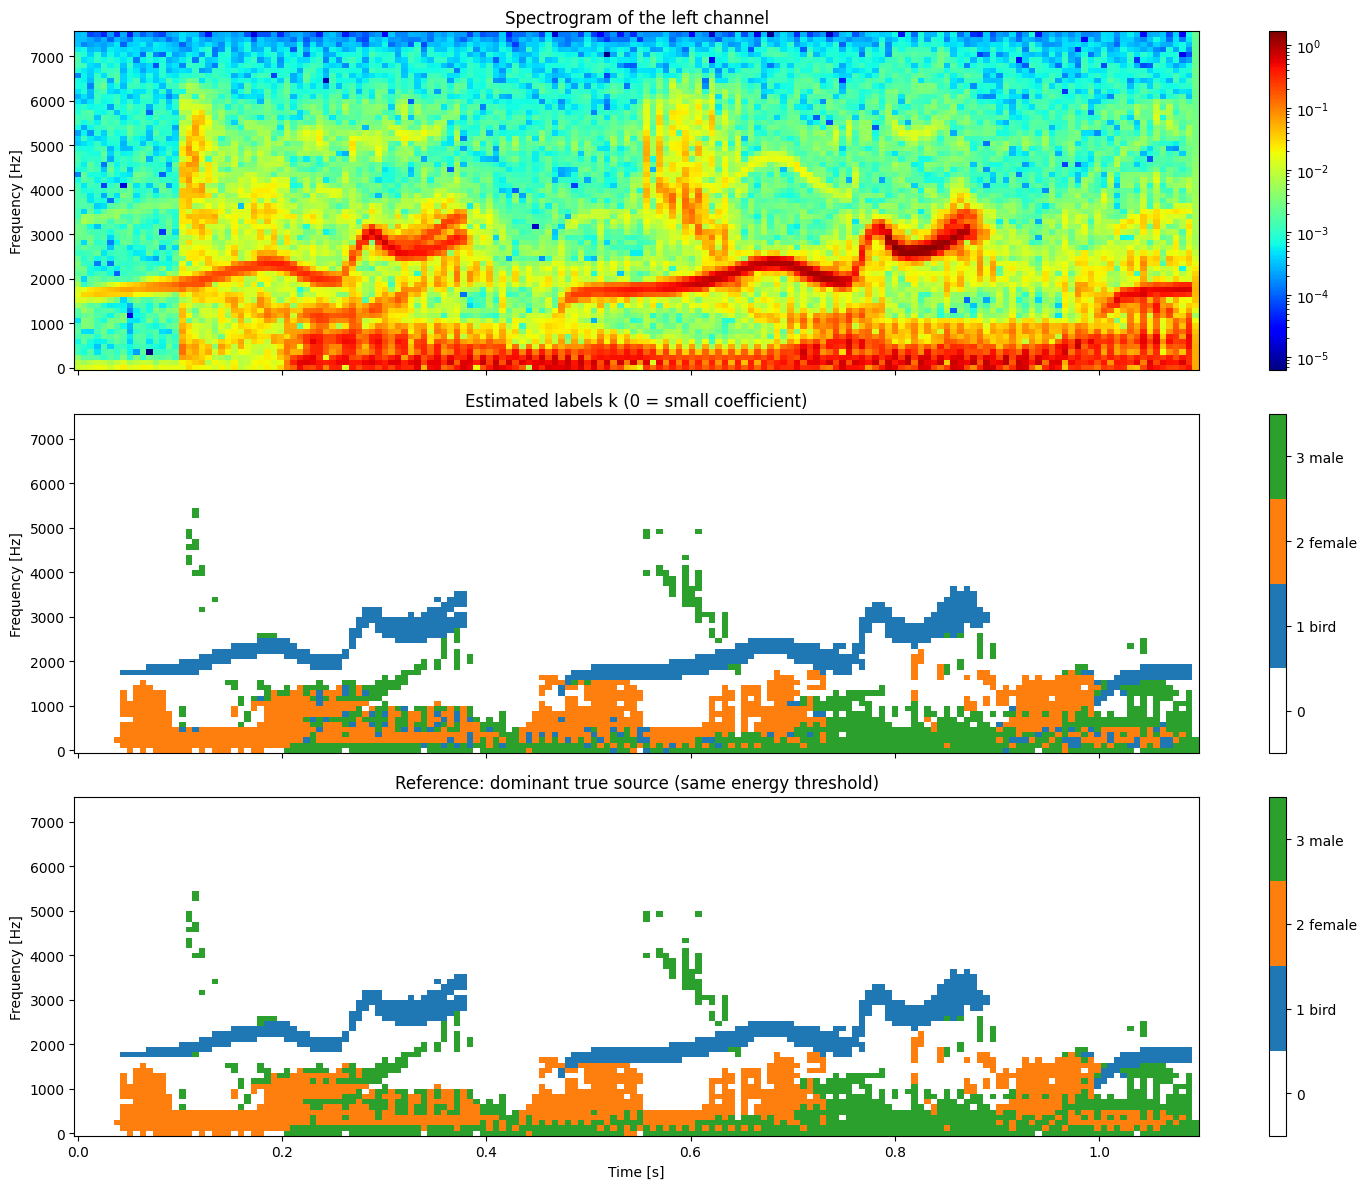

In [32]:
I = labels_denoised.reshape((mf, mt))
I_true = true_dominant.reshape((mf, mt)) * (E > threshold).reshape((mf, mt))

times = np.arange(mt) * (width - q) / fs
freqs = np.arange(mf) * fs / width
cmap_labels = ListedColormap(["white", "tab:blue", "tab:orange", "tab:green"])

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
im0 = axes[0].pcolormesh(times, freqs, np.abs(X[0]), cmap="jet", norm=LogNorm(), shading="auto")
fig.colorbar(im0, ax=axes[0])
axes[0].set_title("Spectrogram of the left channel")
for ax, lab, ttl in [(axes[1], I, "Estimated labels k (0 = small coefficient)"),
                     (axes[2], I_true, "Reference: dominant true source (same energy threshold)")]:
    im = ax.pcolormesh(times, freqs, lab, cmap=cmap_labels, vmin=-0.5, vmax=3.5, shading="auto")
    cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(["0", "1 bird", "2 female", "3 male"])
    ax.set_title(ttl)
for ax in axes:
    ax.set_ylabel("Frequency [Hz]")
axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

**Question 7.** The label map reproduces the structure of the sources very well, and is almost identical to the reference map computed from the true sources:

- the **thin line of the bird** (1700 to 3500 Hz, with the jumps at 0.3 s and 0.8 s) is entirely labelled 1;
- the **low-frequency harmonic regions** are split between the female voice (2, dominant during her syllables at 0.05 to 0.2 s, 0.45 to 0.6 s and 0.9 to 1.0 s) and the male voice (3, dominant below 500 Hz from 0.2 s onwards), following the alternation visible on the spectrograms of the sources;
- the **wideband bursts** of the consonants of the male voice (around 0.1 s and 0.57 s, up to 5000 Hz) are labelled 3.

The errors (about 6.5 % of the significant coefficients) are located where the sources overlap, mostly in the low frequencies where the two voices are simultaneously active, and at the edges of the regions where the energy is small. There, the coefficient is a combination of several sources and its angle lies between the lines, so a binary decision is necessarily imperfect. Each label map defines a binary mask per source, which is the basis of the separation.

### Exercise 5 (optional)

Based on the results obtained in the previous exercise, propose another way to recover the original sources. Listen to the reconstructed sources, and comment on your results.

### Answers to Exercise 5

**Proposed method: binary masking in the STFT domain.** For each source $k$, keep only the coefficients labelled $k$, and take as estimate of $S_k$ on these coefficients the projection of the mixture on the estimated direction:

$$\hat{S}_k(t, f) = \mathbb{1}_{\{\text{label}(t, f) = k\}}\ \langle X(t, f), u_k \rangle,$$

then go back to the time domain with the inverse STFT (`istft`). The projection is the least-squares estimate of $S_k$ when only source $k$ is present, since $\langle S_k u_k, u_k \rangle = S_k$.

For the inverse STFT to reconstruct the signal, the window and the overlap must satisfy the constant overlap-add condition: this is **not** the case for the Hann window with an overlap of only `width`/4 used so far, so the STFT is recomputed with an overlap of 75 %. The quality of the separation is measured by the signal-to-noise ratio between each true source and its estimate, $\mathrm{SNR} = 10 \log_{10}\left(\|s_k\|^2 / \|s_k - \hat{s}_k\|^2\right)$, for several window lengths.

In [33]:
def separate(x, U, fs, width, overlap, threshold=0.0):
    # Binary masking separation in the STFT domain.
    #   U: 2 x n matrix of unit direction vectors (estimated mixing directions)
    # Each coefficient is given to the direction with the largest |projection|, and the source estimate is the
    # projection of the mixture on this direction, masked, then transformed back to the time domain.
    _, _, Xs = stft(x, fs=fs, window="hann", nperseg=width, noverlap=overlap)
    proj = np.einsum("ck,cft->kft", U, Xs)
    lab = np.argmax(np.abs(proj), axis=0)
    energy_tf = np.sum(np.abs(Xs) ** 2, axis=0)
    keep = energy_tf > threshold * energy_tf.max()
    estimates = []
    for k in range(U.shape[1]):
        _, yk = istft(proj[k] * (lab == k) * keep, fs=fs, window="hann", nperseg=width, noverlap=overlap)
        estimates.append(yk[: x.shape[1]])
    return np.array(estimates)


def snr_db(reference, estimate):
    return 10 * np.log10(np.sum(reference ** 2) / np.sum((reference - estimate) ** 2))


print("SNR of the estimated sources [dB] (bird, female, male)")
for w, ov in [(128, 32), (128, 96), (512, 384), (1024, 768), (2048, 1536)]:
    y = separate(x, P, fs, w, ov)
    print("  width %4d, overlap %4d: " % (w, ov), np.round([snr_db(s[k], y[k]) for k in range(n)], 1))

# reference without separation: best single channel / direction for each source
print("  no masking (projection on the direction only):",
      np.round([snr_db(s[k], P[:, k] @ x) for k in range(n)], 1))

SNR of the estimated sources [dB] (bird, female, male)
  width  128, overlap   32:  [8.5 4.2 4.4]
  width  128, overlap   96:  [14.5  8.5  8.8]
  width  512, overlap  384:  [17.6 11.7 11.3]
  width 1024, overlap  768:  [21.  14.1 14.2]
  width 2048, overlap 1536:  [20.2 14.5 14.4]
  no masking (projection on the direction only): [3. 3. 3.]


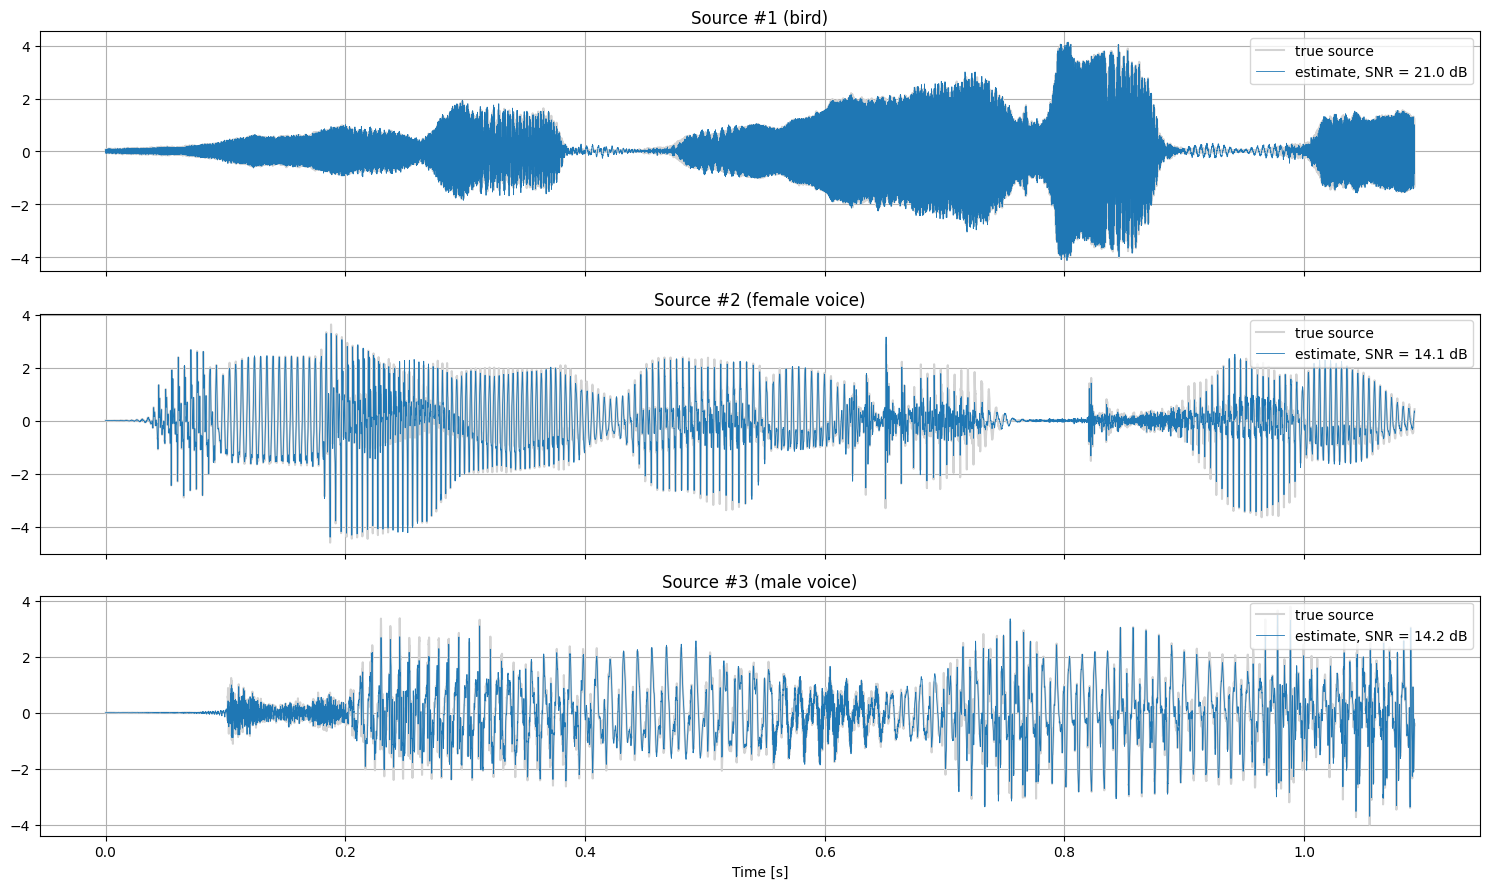

Estimated source #1 (bird):


Estimated source #2 (female voice):


Estimated source #3 (male voice):


In [34]:
width_sep, overlap_sep = 1024, 768
y = separate(x, P, fs, width_sep, overlap_sep)

fig, axes = plt.subplots(n, 1, figsize=(15, 9), sharex=True)
for k in range(n):
    axes[k].plot(t, s[k], color="lightgray", label="true source")
    axes[k].plot(t, y[k], linewidth=0.6, label="estimate, SNR = %.1f dB" % snr_db(s[k], y[k]))
    axes[k].set_title("Source #%d (%s)" % (k + 1, names[k]))
    axes[k].legend(loc="upper right")
    axes[k].grid()
axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

for k in range(n):
    print("Estimated source #%d (%s):" % (k + 1, names[k]))
    display(Audio(y[k], rate=fs))

**Results.**

| STFT | bird | female | male |
| --- | --- | --- | --- |
| no masking, projection on $u_k$ only | 3.0 dB | 3.0 dB | 3.0 dB |
| `width` = 128, overlap 32 (non-COLA) | 8.5 dB | 4.2 dB | 4.4 dB |
| `width` = 128, overlap 96 | 14.5 dB | 8.5 dB | 8.8 dB |
| `width` = 512, overlap 384 | 17.6 dB | 11.7 dB | 11.3 dB |
| **`width` = 1024, overlap 768** | **21.0 dB** | **14.1 dB** | **14.2 dB** |
| `width` = 2048, overlap 1536 | 20.2 dB | 14.5 dB | 14.4 dB |

- **Without masking**, projecting the stereo mixture on one direction cannot separate three sources with two channels: the other sources are only attenuated by $\cos 60° = 0.5$, and the SNR is 3 dB. The time-frequency masking brings **11 to 18 dB** more: this is the gain given by sparsity.
- **The overlap matters**: with the parameters of Exercise 4 (overlap of `width`/4), the Hann windows do not add up to a constant, so the inverse STFT itself distorts the signal and the SNRs are poor. With 75 % overlap, the same masks give 6 dB more.
- **The window length matters**: longer windows resolve the harmonics of the voices better (frequency step 15 Hz for 1024 samples, against 117 Hz for 128), so the harmonics of the two voices fall into different coefficients and the sources overlap less. Beyond 1024 samples (68 ms), the bird's quick frequency changes and the syllables of the voices are no longer well localised in time, and the results stop improving.
- **The bird is the best separated source (21 dB)**: its thin line rarely overlaps with the voices. The two voices, which share the low frequencies, reach about 14 dB.

**Listening.** The audio players above allow the estimates to be compared with the original sources of the beginning of the notebook. The waveforms already show what to expect: the envelope of each estimate follows the true source closely, including its silences (for example the pause of the bird around 0.4 s and the absence of the male voice before 0.1 s), so the other sources are strongly attenuated. With about 14 dB for the voices, some crosstalk from the other voice remains, mainly where the two voices overlap in the low frequencies. Binary masks are also known to produce a slightly metallic, bubbling artefact ("musical noise"), because isolated coefficients are switched on and off from one frame to the next. Possible improvements would be soft masks (weighting each coefficient by its probability of belonging to each source instead of a binary decision), smoothing the masks in time and frequency, or keeping the low-energy coefficients instead of setting them to zero.